### 📈 **Darts: A Modern Time Series Forecasting Library**

Darts is a Python library designed to make time series forecasting and anomaly detection intuitive and powerful. It supports a wide range of models—from classical statistical approaches like ARIMA to cutting-edge deep learning architectures.

🔧 Key Features
- Unified API: All models use fit() and predict() methods, similar to scikit-learn.
- Model Variety: Includes ARIMA, Prophet, RNNs, Transformers, and more.
- Multivariate Support: Handles both univariate and multivariate time series.
- Probabilistic Forecasting: Offers uncertainty estimates for predictions.
- Backtesting & Ensembling: Easily evaluate and combine models.
- External Data Integration: Incorporate covariates and exogenous variables.

🧠 Use Cases
- Demand forecasting
- Predictive maintenance
- Financial time series analysis
- Energy consumption modeling

In [2]:
 ! pip install darts

# Import Other Packages and Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
import warnings
warnings.filterwarnings('ignore')

Read in dataset as a numpy array.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /LSTM/Hourly-train.csv',
                 header=None).values.squeeze()
df

array([['V1', 'V2', 'V3', ..., 'V959', 'V960', 'V961'],
       ['H1', '605', '586', ..., nan, nan, nan],
       ['H2', '3124', '2990', ..., nan, nan, nan],
       ...,
       ['H412', '19', '30', ..., '73', '39', '36'],
       ['H413', '21', '16', ..., '53', '38', '46'],
       ['H414', '15', '13', ..., '35', '26', '17']], dtype=object)

In [5]:
# Remove the first row and first column, convert remaining values to floats, and transpose.
df = df[1:,1:].astype(float).T
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [  nan,   nan,   nan, ...,   73.,   53.,   35.],
       [  nan,   nan,   nan, ...,   39.,   38.,   26.],
       [  nan,   nan,   nan, ...,   36.,   46.,   17.]])

In [6]:
# Identify and remove any rows that contain 'NaN' values.
nan_rows = np.isnan(df).any(axis=1)
df = df[~nan_rows]
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [ 752., 3460., 1581., ...,   18.,   17.,   13.],
       [ 739., 3248., 1570., ...,   13.,   16.,   17.],
       [ 684., 3105., 1518., ...,   17.,   15.,   21.]])

In [7]:
len(df)

700

In [8]:
# Convert to pandas dataframe
df = pd.DataFrame(df)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
0,605.0,3124.0,1828.0,6454.0,4263.0,5780.0,52817.0,32479.0,39455.0,513.0,...,68.0,21.0,214.0,19.0,31.0,153.0,24.0,19.0,21.0,15.0
1,586.0,2990.0,1806.0,6324.0,4297.0,5497.0,51773.0,31018.0,38279.0,512.0,...,48.0,15.0,238.0,31.0,39.0,196.0,30.0,30.0,16.0,13.0
2,586.0,2862.0,1897.0,6075.0,4236.0,5306.0,50907.0,30033.0,36944.0,506.0,...,33.0,15.0,130.0,25.0,22.0,163.0,22.0,12.0,17.0,13.0
3,559.0,2809.0,1750.0,5949.0,4080.0,5178.0,50224.0,27716.0,35984.0,500.0,...,21.0,17.0,69.0,23.0,17.0,131.0,14.0,16.0,19.0,16.0
4,511.0,2544.0,1679.0,5858.0,3883.0,5235.0,49496.0,25067.0,33721.0,490.0,...,30.0,15.0,68.0,14.0,13.0,82.0,19.0,13.0,16.0,26.0


Because we don't have any time information, we will insert dummy time information.

In [9]:
start_date = pd.to_datetime('2000-01-01 00:00:00')
series = TimeSeries.from_times_and_values(pd.date_range(
                                          start=start_date,
                                          periods = len(df),
                                          freq='H'),
                                          df.values
                                          )


In [10]:
df_with_time = series.to_dataframe()
df_with_time.head()

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
2000-01-01 00:00:00,605.0,3124.0,1828.0,6454.0,4263.0,5780.0,52817.0,32479.0,39455.0,513.0,...,68.0,21.0,214.0,19.0,31.0,153.0,24.0,19.0,21.0,15.0
2000-01-01 01:00:00,586.0,2990.0,1806.0,6324.0,4297.0,5497.0,51773.0,31018.0,38279.0,512.0,...,48.0,15.0,238.0,31.0,39.0,196.0,30.0,30.0,16.0,13.0
2000-01-01 02:00:00,586.0,2862.0,1897.0,6075.0,4236.0,5306.0,50907.0,30033.0,36944.0,506.0,...,33.0,15.0,130.0,25.0,22.0,163.0,22.0,12.0,17.0,13.0
2000-01-01 03:00:00,559.0,2809.0,1750.0,5949.0,4080.0,5178.0,50224.0,27716.0,35984.0,500.0,...,21.0,17.0,69.0,23.0,17.0,131.0,14.0,16.0,19.0,16.0
2000-01-01 04:00:00,511.0,2544.0,1679.0,5858.0,3883.0,5235.0,49496.0,25067.0,33721.0,490.0,...,30.0,15.0,68.0,14.0,13.0,82.0,19.0,13.0,16.0,26.0


# EDA

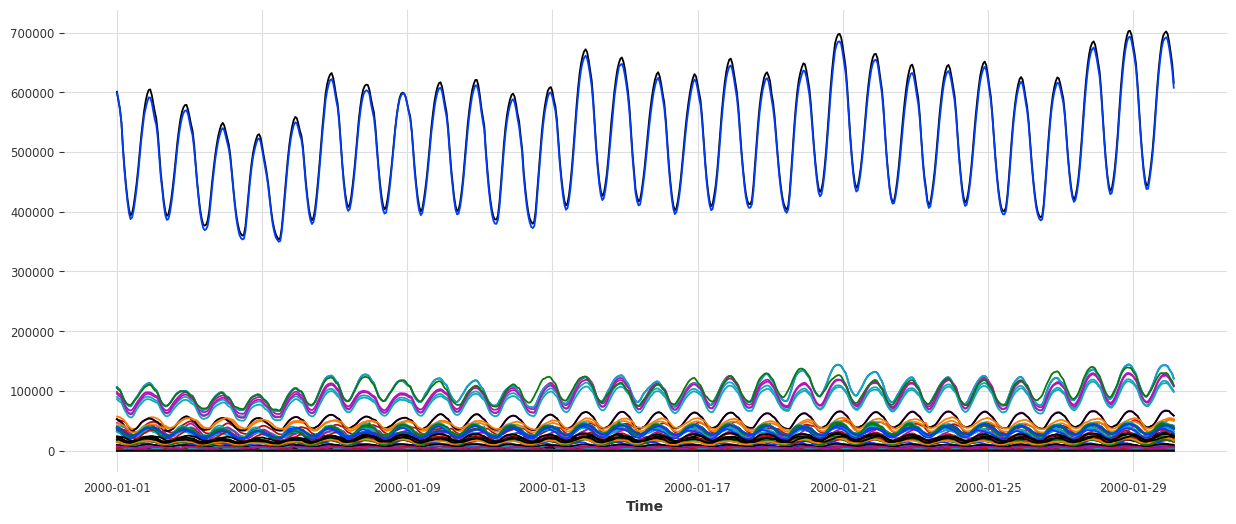

In [11]:
# Plot the multiple time-series

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_with_time.index, df.values)
plt.xlabel('Time')
plt.show()

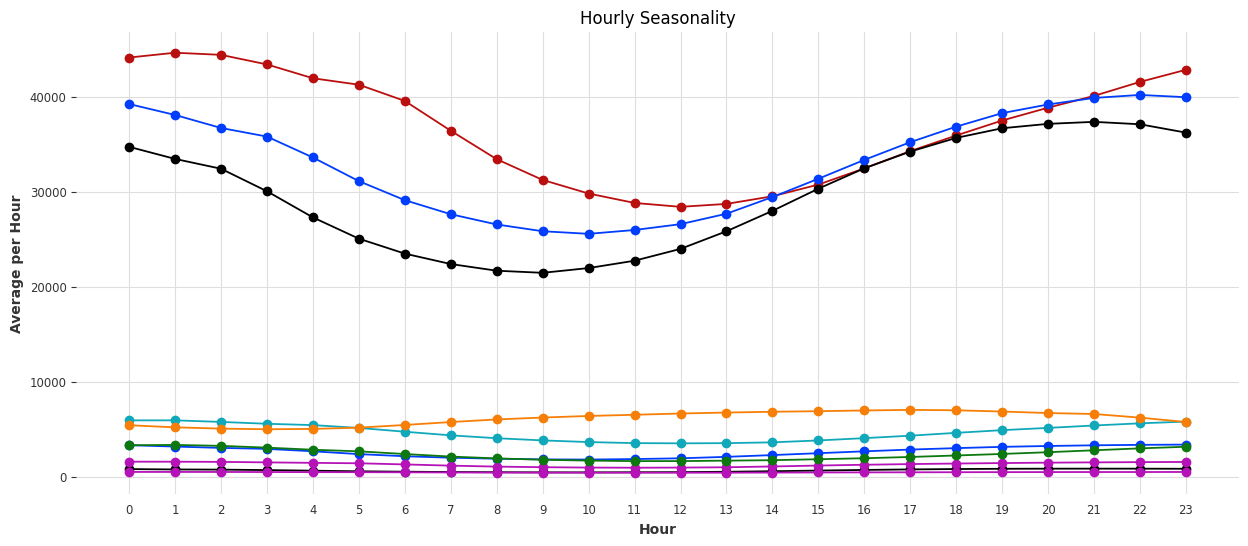

In [12]:
# Hourly Seasonality - plot the first 10 time series

fig, ax = plt.subplots(figsize=(15, 6))
hourly_means = df_with_time.groupby(df_with_time.index.hour).mean()
plt.plot(hourly_means.iloc[:,:10],marker = 'o')
plt.xlabel('Hour')
plt.ylabel('Average per Hour')
plt.title('Hourly Seasonality')
plt.xticks(range(24))
plt.show()

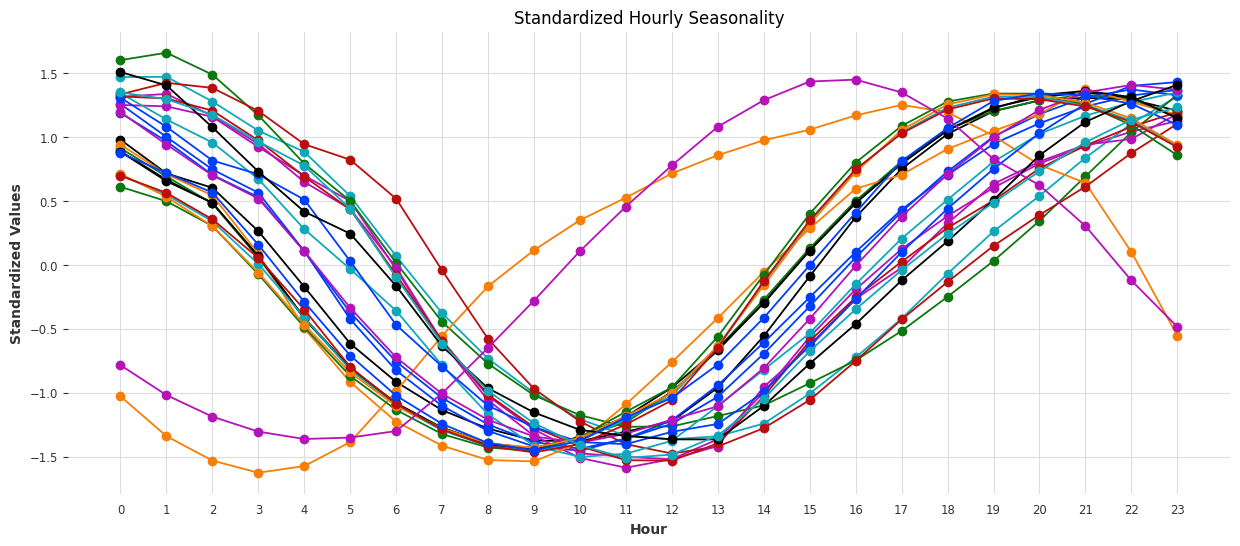

In [13]:
# Standardizing the hourly means

hourly_means_std = (hourly_means - np.mean(hourly_means,axis=0)) / np.std(hourly_means,axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(hourly_means_std.iloc[:,:25],marker = 'o')
plt.xlabel('Hour')
plt.ylabel('Standardized Values')
plt.title('Standardized Hourly Seasonality')
plt.xticks(range(24))
plt.show()


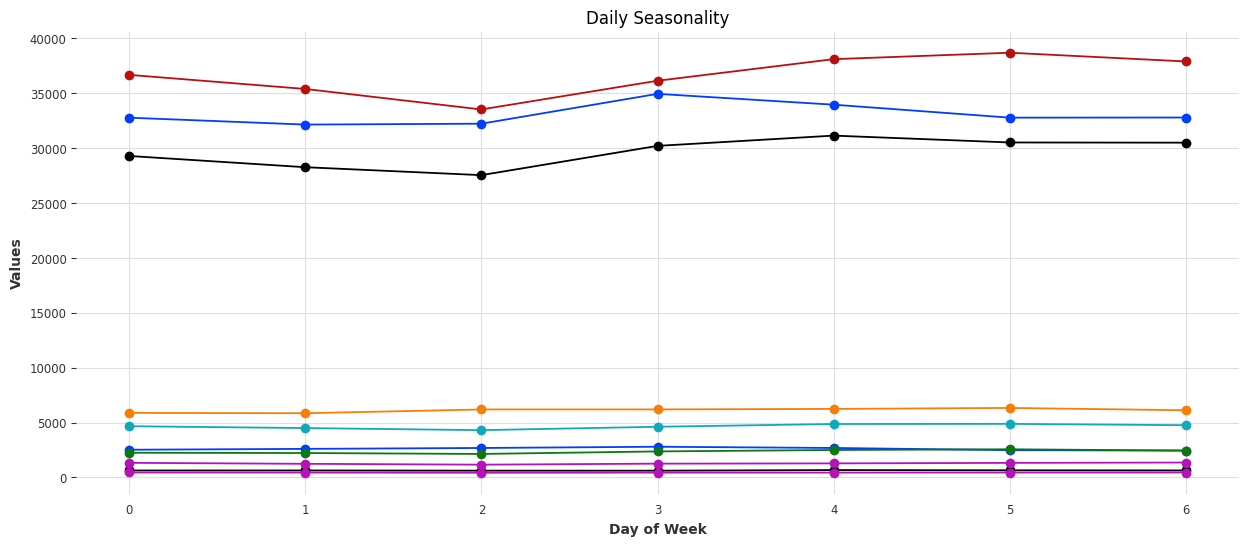

In [14]:
# Weekly Seasonality

# Daily Seasonality Plot

daily_means = df_with_time.groupby(df_with_time.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(daily_means.iloc[:,:10],marker = 'o')
plt.xlabel('Day of Week')
plt.ylabel('Values')
plt.title('Daily Seasonality')
plt.xticks(range(7))
plt.show()

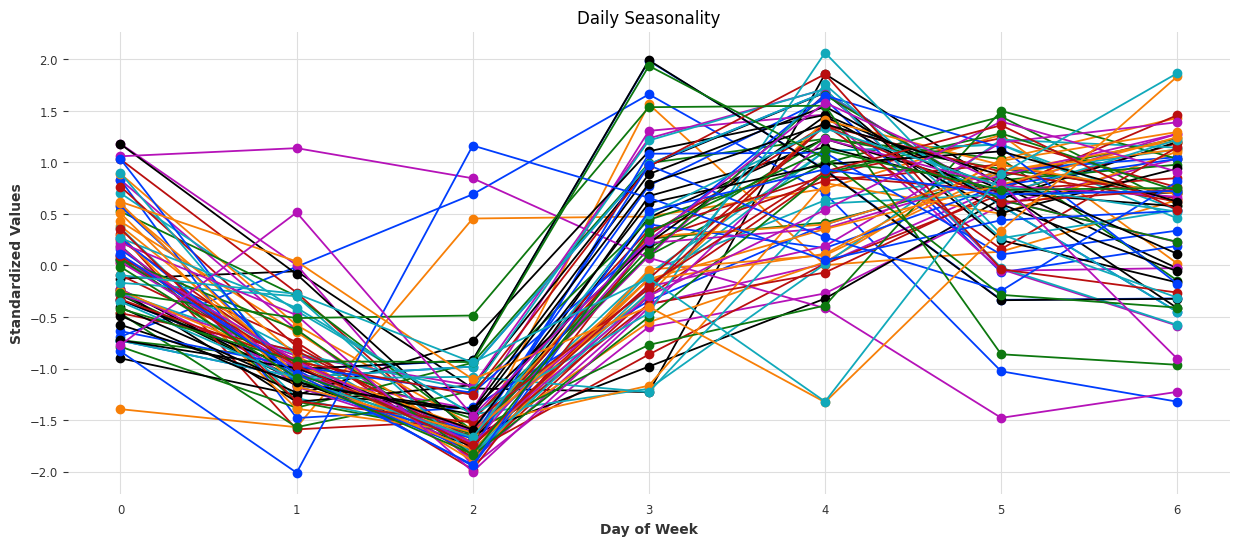

In [15]:
daily_means_std = (daily_means - np.mean(daily_means,axis=0)) / np.std(daily_means,axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(daily_means_std.iloc[:,:75],marker = 'o')
plt.xlabel('Day of Week')
plt.ylabel('Standardized Values')
plt.title('Daily Seasonality')
plt.xticks(range(7))
plt.show()

# Prepare for LSTM

In [16]:
# Build the covariate series

# Hourly

hourly_series = datetime_attribute_timeseries(
                  series,
                  attribute = 'hour',
                  one_hot = True
                  )

# Daily

weekday_series = datetime_attribute_timeseries(
                  hourly_series,
                  attribute = 'dayofweek',
                  one_hot = True
                  )

In [17]:
# Instantiate a Scaler function and apply to the multiple series

scaler = Scaler()
scaled_series = scaler.fit_transform(series)

In [18]:
# Stack the covariates

scaled_covariates = TimeSeries.stack(hourly_series, weekday_series)
scaled_covariates

<TimeSeries (time: 700, component: 31, sample: 1)> Size: 174kB
array([[[1.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]],

       [[0.],
        [0.],
        [1.],
        ...,
...
        ...,
        [0.],
        [0.],
        [1.]],

       [[0.],
        [0.],
        [1.],
        ...,
        [0.],
        [0.],
        [1.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [1.]]])
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-30T03:00:00
  * component  (component) object 248B 'hour_0' 'hour_1' ... 'dayofweek_6'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

#LSTM

- `training_length` = `input_chunk_length` + `forecast_horizon`   
- `input_chunk_length` > `forecast_horizon`

In [19]:
# Define input and output parameters

input_chunk_length = 72
forecasting_horizon = 48
training_length = input_chunk_length + forecasting_horizon

In [20]:
# Define the LSTM model

rnn = RNNModel(
    model = 'LSTM',
    hidden_dim = 20,
    n_rnn_layers = 2,
    dropout = 0.1,
    n_epochs = 10,
    optimizer_kwargs = {'lr': 3e-3},
    model_name = 'lstm_model',
    random_state = 42,
    training_length = training_length,
    input_chunk_length = input_chunk_length,
    pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
    save_checkpoints = True,
    force_reset = True
    )

In [21]:
# Fit the model

rnn.fit(scaled_series,
        future_covariates=scaled_covariates,
        verbose = True
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=2, dropout=0.1, training_length=120, n_epochs=10, optimizer_kwargs={'lr': 0.003}, model_name=lstm_model, random_state=42, input_chunk_length=72, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, save_checkpoints=True, force_reset=True)

In [27]:
# Cross Validation with Rolling Forecast Window

cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = scaled_covariates,
                              start = df.shape[0] - 200,  # arbitrarily chosen
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 24,   # since we're forecasting 48 hours out
                              last_points_only = False
                              )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [36]:
# CV Results

cv

[<TimeSeries (time: 48, component: 414, sample: 1)> Size: 159kB
 array([[[0.8574078 ],
         [0.70467901],
         [0.68046393],
         ...,
         [0.1727705 ],
         [0.34277675],
         [0.11032883]],
 
        [[0.86986337],
         [0.73263469],
         [0.72828566],
         ...,
         [0.1292013 ],
         [0.28663207],
         [0.08207554]],
 
        [[0.8661196 ],
         [0.73237383],
         [0.75654778],
         ...,
 ...
         ...,
         [0.34864012],
         [0.44335482],
         [0.21905703]],
 
        [[0.73136365],
         [0.57665165],
         [0.49977591],
         ...,
         [0.29242798],
         [0.4262578 ],
         [0.18630686]],
 
        [[0.79875321],
         [0.64958838],
         [0.60750187],
         ...,
         [0.22067597],
         [0.38352904],
         [0.14613688]]])
 Coordinates:
   * time       (time) datetime64[ns] 384B 2000-01-21T20:00:00 ... 2000-01-23T...
   * component  (component) object 3kB '0' '1' 

In [39]:
# Outcome of the cv analysis

rmse = []

for i in range(len(cv)):
  # Generate predictions to go
  predictions = TimeSeries.to_dataframe(scaler.inverse_transform(cv[i]))

  # Get actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = series[start:end]

  # Calculate RMSE error
  rmse.append(root_mean_squared_error(actuals, predictions))

np.mean(rmse)

np.float64(516.1228585124653)

# Visualize the Predictions (4 examples)

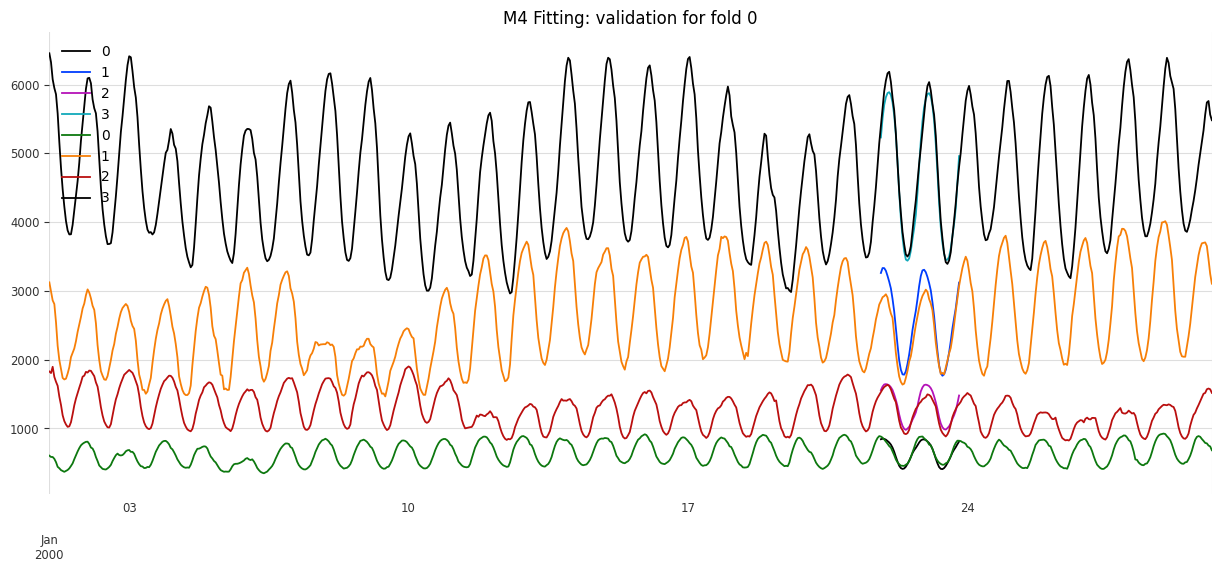

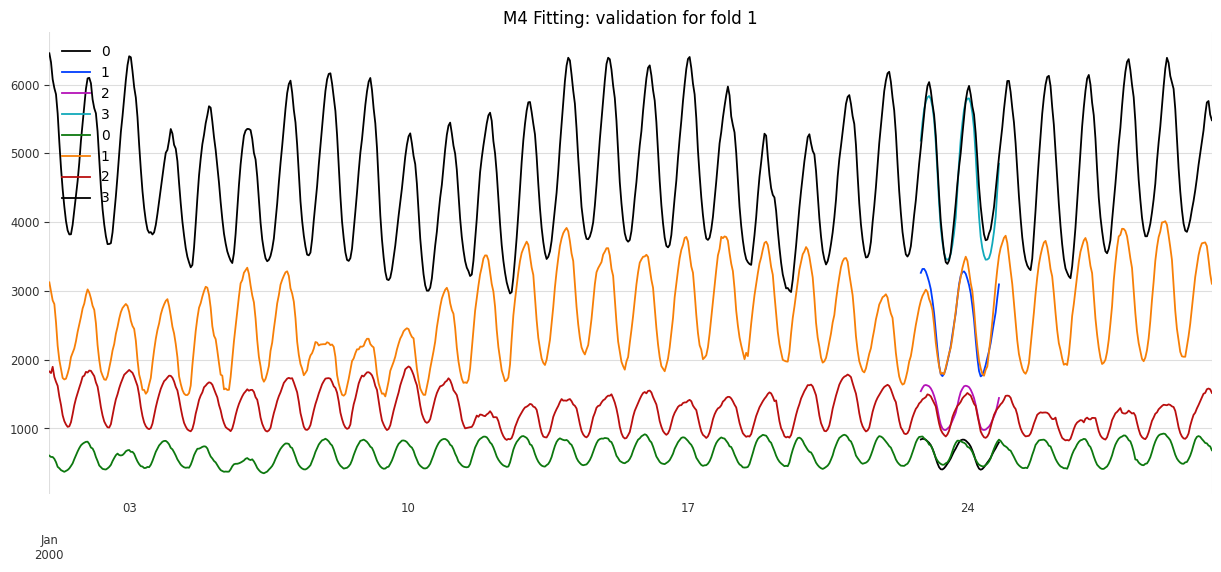

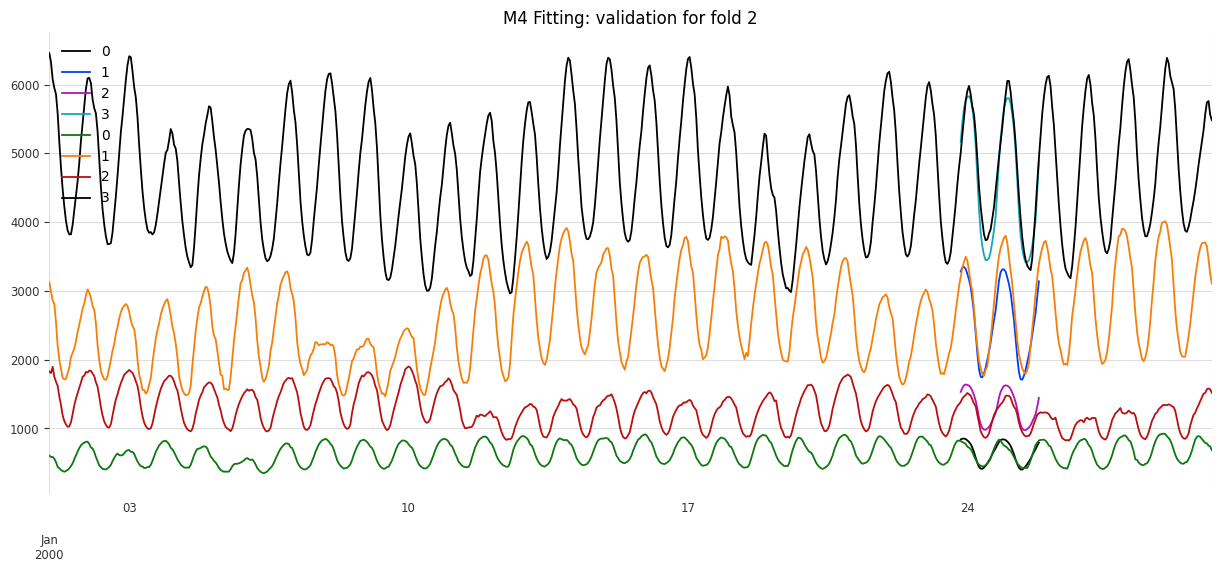

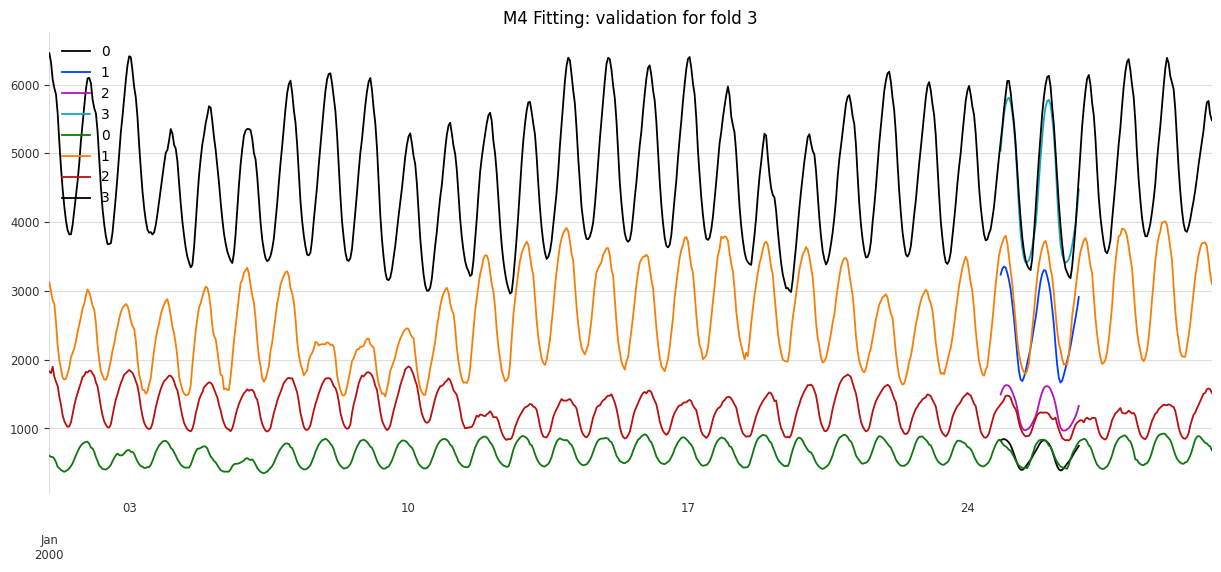

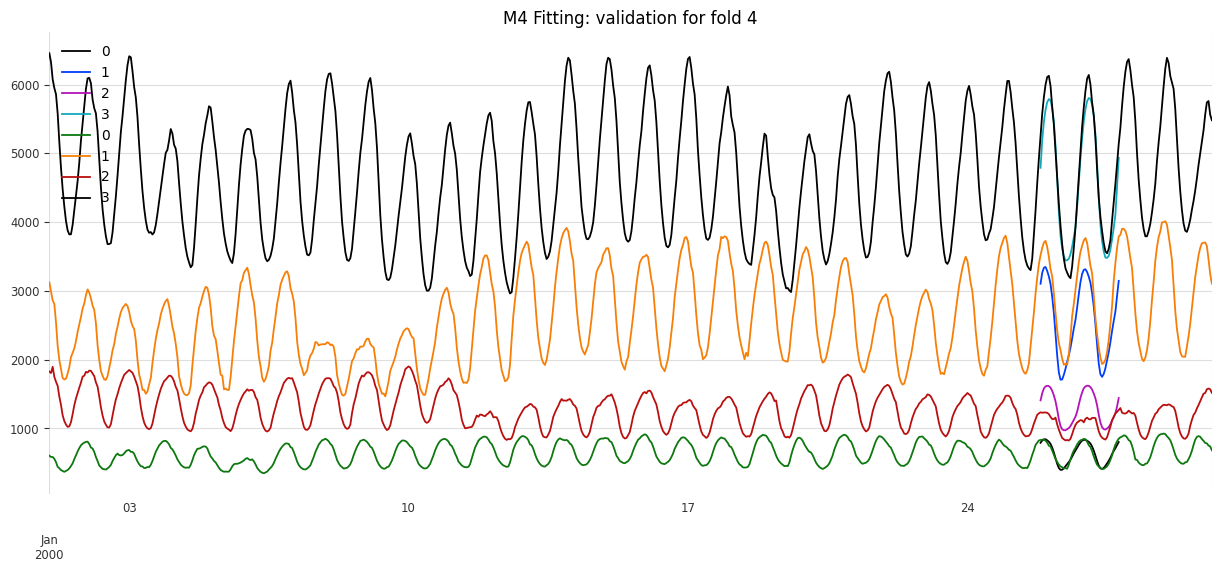

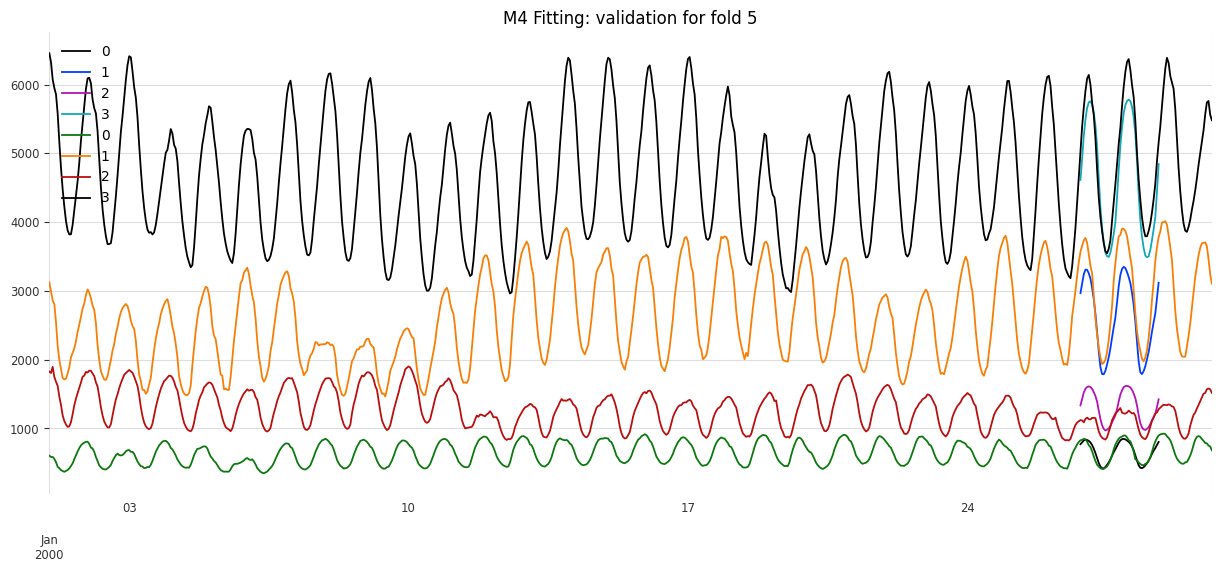

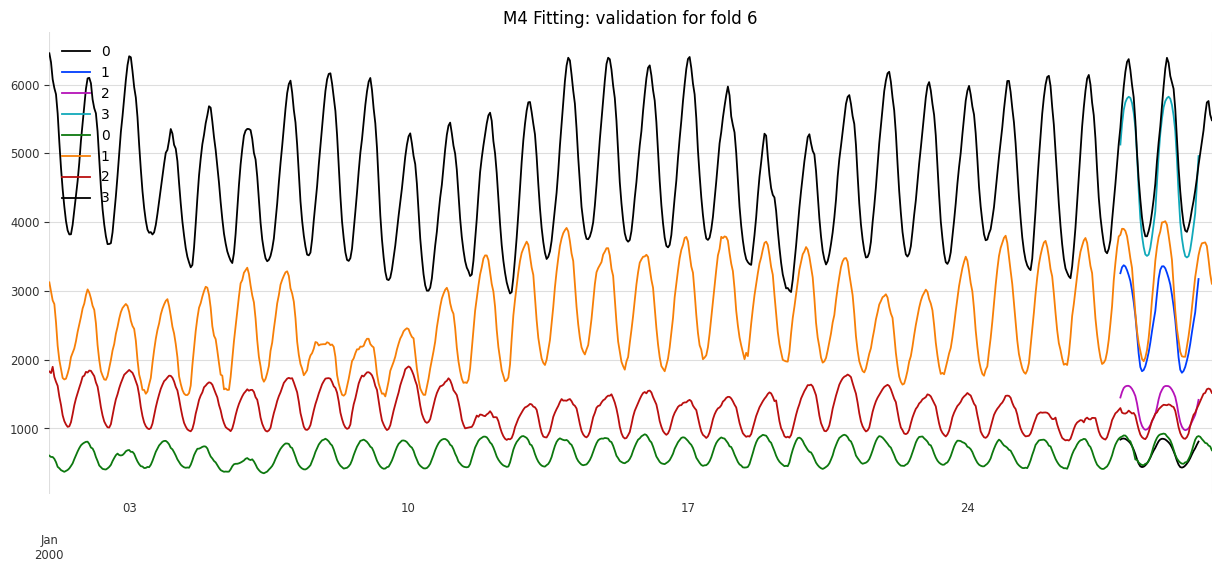

In [62]:
for i in range(len(cv)):

  plt.figure(figsize=(15, 6))

  # Convert to pandas DataFrame before plotting and plot a subset
  predictions_df = scaler.inverse_transform(cv[i]).to_dataframe()
  predictions_df.iloc[:,:4].plot(label = 'Predictions',ax=plt.gca())
  series.iloc[:,:4].plot(label = 'Actuals', ax=plt.gca())
  plt.title(f"M4 Fitting: validation for fold {i}")
  plt.legend()
  plt.show()

# Hyperparameter Tuning

In [ ]:
# Set up the parameter grid

param_grid = {'n_rnn_layers': [1, 2],
              'hidden_dim': [10, 20],
              'dropout': [0.1, 0.2],
              'n_epochs': [5, 10],
              'lr': [3e-3],
              'training_length': [input_chunk_length + forecasting_horizon],
              'input_chunk_length': [input_chunk_length]
              }


In [ ]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

In [ ]:
# Create a empty list for storing the tuning results

rmse = []

for params in all_params:

  # Build the model

  rnn = RNNModel(
      model = 'LSTM',
      hidden_dim = params['hidden_dim'],
      n_rnn_layers = params['n_rnn_layers'],
      dropout = params['dropout'],
      n_epochs = params['n_epochs'],
      optimizer_kwargs = {'lr': params['lr']},
      model_name = 'lstm_model',
      random_state = 42,
      training_length = params['training_length'],
      input_chunk_length = params['input_chunk_length'],
      pl_trainer_kwargs = {'accelerator': 'gpu', 'devices': [0]},
      save_checkpoints = True,
      force_reset = True
      )

  # Cross Validation with Rolling Forecast Window

  cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = scaled_covariates,
                              start = df.shape[0] - 180,
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 10,
                              last_points_only = False
                              )

  # Calculate RMSE error

  rmse_cv = []

  for i in range(len(cv)):
    predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))
    rmse_cv.append(root_mean_squared_error(actuals, predictions))

  mean_rmse = np.mean(rmse_cv)    # mean_rmse for a particular cv run
  rmse.append(mean_rmse)



In [ ]:
grid = ParameterGrid(param_grid)
tuning_results = pd.DataFrame(grid)
tuning_results['rmse'] = rmse
tuning_results

In [ ]:
# Get the best parameters

best_params = tuning_results.loc[tuning_results['rmse'] == tuning_results['rmse'].min()]
best_params = best_params.drop('rmse', axis=1)
best_params.to_csv('best_params.csv')

In [ ]:
best_params